# Event-Driven Prediction of Stock Price Direction for Romgaz (SNG.RO)

**Course:** Machine Learning / Data Analysis Lab

**Objective:** Predict next-day stock price direction using price-based features and event/sentiment features.

---

## Table of Contents
1. [Load and Inspect Data](#1-load-and-inspect-data)
2. [Train/Test Split (Time-Based)](#2-traintestsplit-time-based)
3. [Experiment 1: Descriptive Analysis of Events](#3-experiment-1-descriptive-analysis-of-events)
4. [Experiment 2: Baseline ML Model (Price-Only)](#4-experiment-2-baseline-ml-model-price-only)
5. [Experiment 3: Models with Events and Sentiment](#5-experiment-3-models-with-events-and-sentiment)
6. [Results Comparison](#6-results-comparison)
7. [Summary & Discussion](#7-summary--discussion)


## 1. Load and Inspect Data

We begin by loading the dataset and performing basic exploratory data analysis to understand the structure and distribution of our data.


In [88]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


In [89]:
# Load the dataset
df = pd.read_csv('romgaz_prices_events_with_sentiment_for_model.csv')

# Parse Date column as datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date to ensure chronological order
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset loaded successfully with {len(df)} rows and {len(df.columns)} columns.")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")


Dataset loaded successfully with 215 rows and 21 columns.
Date range: 2025-01-10 00:00:00 to 2025-11-14 00:00:00


In [90]:
# Display first few rows
print("\n=== First 5 rows of the dataset ===")
df.head()



=== First 5 rows of the dataset ===


,Date,Price,Open,High,Low,Vol.,Change %,Close,Return_t,Return_next,...,Return_t-1,Return_t-2,ticker,category,title,description,impact_sign,impact_label,event_count,event_today
0,2025-01-10,5.38,5.46,5.49,5.38,601.65K,-0.55%,5.38,-0.005561,-0.014982,...,0.018657,0.022858,NaN,NaN,NaN,NaN,0,neutral,0,0
1,2025-01-13,5.30,5.40,5.40,5.28,348.20K,-1.49%,5.30,-0.014982,0.016839,...,-0.005561,0.018657,NaN,NaN,NaN,NaN,0,neutral,0,0
2,2025-01-14,5.39,5.30,5.39,5.28,264.07K,1.70%,5.39,0.016839,-0.005581,...,-0.014982,-0.005561,NaN,NaN,NaN,NaN,0,neutral,0,0
3,2025-01-15,5.36,5.39,5.39,5.35,174.91K,-0.56%,5.36,-0.005581,0.005581,...,0.016839,-0.014982,NaN,NaN,NaN,NaN,0,neutral,0,0
4,2025-01-16,5.39,5.36,5.39,5.28,713.82K,0.56%,5.39,0.005581,-0.007449,...,-0.005581,0.016839,NaN,NaN,NaN,NaN,0,neutral,0,0


In [91]:
# Display dataset information
print("\n=== Dataset Information ===")
df.info()



=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            215 non-null    datetime64[ns]
 1   Price           215 non-null    float64       
 2   Open            215 non-null    float64       
 3   High            215 non-null    float64       
 4   Low             215 non-null    float64       
 5   Vol.            215 non-null    object        
 6   Change %        215 non-null    object        
 7   Close           215 non-null    float64       
 8   Return_t        215 non-null    float64       
 9   Return_next     215 non-null    float64       
 10  Direction_next  215 non-null    int64         
 11  Return_t-1      215 non-null    float64       
 12  Return_t-2      215 non-null    float64       
 13  ticker          22 non-null     object        
 14  category        22 non-null  

In [92]:
# Display descriptive statistics for numeric columns
print("\n=== Descriptive Statistics ===")
df.describe()



=== Descriptive Statistics ===


,Date,Price,Open,High,Low,Close,Return_t,Return_next,Direction_next,Return_t-1,Return_t-2,impact_sign,event_count,event_today
count,215,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,2025-06-14 21:39:20.930232576,7.040093,7.027674,7.093860,6.964512,7.040093,0.002848,0.002939,0.553488,0.002935,0.003041,0.037209,0.102326,0.102326
min,2025-01-10 00:00:00,5.300000,5.270000,5.320000,5.240000,5.300000,-0.044835,-0.044835,0.000000,-0.044835,-0.044835,-1.000000,0.000000,0.000000
25%,2025-03-27 12:00:00,5.915000,5.915000,5.960000,5.865000,5.915000,-0.004635,-0.004049,0.000000,-0.004635,-0.004635,0.000000,0.000000,0.000000
50%,2025-06-17 00:00:00,6.880000,6.850000,6.900000,6.750000,6.880000,0.001665,0.001676,1.000000,0.001676,0.001679,0.000000,0.000000,0.000000
75%,2025-09-01 12:00:00,8.055000,8.085000,8.210000,8.010000,8.055000,0.010170,0.010196,1.000000,0.010196,0.010204,0.000000,0.000000,0.000000
max,2025-11-14 00:00:00,10.000000,10.000000,10.300000,9.980000,10.000000,0.061907,0.061907,1.000000,0.061907,0.061907,1.000000,1.000000,1.000000
std,NaN,1.328529,1.325681,1.348628,1.315480,1.328529,0.013465,0.013474,0.498291,0.013507,0.013573,0.287613,0.303783,0.303783


### 1.1 Distribution Analysis


In [93]:
# Check distribution of Direction_next (target variable)
print("\n=== Target Variable Distribution ===")
direction_counts = df['Direction_next'].value_counts().sort_index()
print(f"\nDirection_next distribution:")
print(direction_counts)
print(f"\nPercentages:")
print(direction_counts / len(df) * 100)

# Interpretation
up_pct = (direction_counts[1] / len(df) * 100) if 1 in direction_counts.index else 0
print(f"\nInterpretation: {up_pct:.1f}% of days show upward movement (Direction_next=1).")



=== Target Variable Distribution ===

Direction_next distribution:
Direction_next
0     96
1    119
Name: count, dtype: int64

Percentages:
Direction_next
0    44.651163
1    55.348837
Name: count, dtype: float64

Interpretation: 55.3% of days show upward movement (Direction_next=1).


In [94]:
# Check event occurrence
print("\n=== Event Occurrence ===")
event_counts = df['event_today'].value_counts().sort_index()
print(f"\nevent_today distribution:")
print(event_counts)
n_event_days = event_counts[1] if 1 in event_counts.index else 0
print(f"\n{n_event_days} days ({n_event_days/len(df)*100:.1f}%) have at least one event.")



=== Event Occurrence ===

event_today distribution:
event_today
0    193
1     22
Name: count, dtype: int64

22 days (10.2%) have at least one event.


In [95]:
# Check impact_label distribution
print("\n=== Event Sentiment Distribution ===")
impact_counts = df[df['event_today']==1]['impact_label'].value_counts()
print(f"\nimpact_label distribution (event days only):")
print(impact_counts)
print(f"\nPercentages:")
print(impact_counts / impact_counts.sum() * 100)



=== Event Sentiment Distribution ===

impact_label distribution (event days only):
impact_label
positive    13
negative     5
neutral      4
Name: count, dtype: int64

Percentages:
impact_label
positive    59.090909
negative    22.727273
neutral     18.181818
Name: count, dtype: float64


**Key Observations:**
- The dataset contains daily trading data for Romgaz stock with both price and event information.
- The target variable `Direction_next` shows the class balance for predicting next-day price movement.
- Events are relatively sparse, occurring on a small fraction of trading days.
- Event sentiment is distributed across positive, neutral, and negative categories.


## 2. Train/Test Split (Time-Based)

For time-series data, we use a temporal split rather than random sampling to avoid look-ahead bias. 

**Note**: The dataset contains data from January 2025 to November 2025. We'll use August 1, 2025 as the split date, giving us approximately 70% of data for training (Jan-Jul) and 30% for testing (Aug-Nov).


In [96]:
# Define split date
# Dataset spans from 2025-01-10 to 2025-11-14
# Using 2025-08-01 as split (approximately 70% train, 30% test)
split_date = pd.Timestamp('2025-08-01')

# Create train and test sets based on date
train_df = df[df['Date'] < split_date].copy()
test_df = df[df['Date'] >= split_date].copy()

print(f"\n=== Train/Test Split ===")
print(f"Split date: {split_date.date()}")
print(f"\nTrain set:")
print(f"  - Size: {len(train_df)} rows")
print(f"  - Date range: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"\nTest set:")
print(f"  - Size: {len(test_df)} rows")
print(f"  - Date range: {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

# Check if split is reasonable
if len(test_df) < 20:
    print("\n⚠️ Warning: Test set is very small. Consider adjusting the split date if needed.")
if len(train_df) < 50:
    print("\n⚠️ Warning: Train set is very small. Consider adjusting the split date if needed.")



=== Train/Test Split ===
Split date: 2025-08-01

Train set:
  - Size: 140 rows
  - Date range: 2025-01-10 to 2025-07-31

Test set:
  - Size: 75 rows
  - Date range: 2025-08-01 to 2025-11-14


In [97]:
# Prepare target variable (y) for both sets
y_train = train_df['Direction_next'].values
y_test = test_df['Direction_next'].values

print(f"\n=== Target Variable Summary ===")
print(f"Train set - Direction_next distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set - Direction_next distribution:")
print(pd.Series(y_test).value_counts().sort_index())



=== Target Variable Summary ===
Train set - Direction_next distribution:
0    65
1    75
Name: count, dtype: int64

Test set - Direction_next distribution:
0    31
1    44
Name: count, dtype: int64


## 3. Experiment 1: Descriptive Analysis of Events

Before building predictive models, we conduct an "event study" style analysis to understand how events and their sentiment relate to next-day returns.


In [98]:
# Split data into event and non-event days
non_event_days = df[df['event_today'] == 0]
event_days = df[df['event_today'] == 1]

# Further split event days by sentiment
event_negative = df[(df['event_today'] == 1) & (df['impact_sign'] == -1)]
event_neutral = df[(df['event_today'] == 1) & (df['impact_sign'] == 0)]
event_positive = df[(df['event_today'] == 1) & (df['impact_sign'] == 1)]

print(f"\n=== Event Groups ===")
print(f"Non-event days: {len(non_event_days)}")
print(f"Event days (total): {len(event_days)}")
print(f"  - Negative sentiment: {len(event_negative)}")
print(f"  - Neutral sentiment: {len(event_neutral)}")
print(f"  - Positive sentiment: {len(event_positive)}")



=== Event Groups ===
Non-event days: 193
Event days (total): 22
  - Negative sentiment: 5
  - Neutral sentiment: 4
  - Positive sentiment: 13


In [99]:
# Function to compute descriptive statistics
def compute_return_stats(data, group_name):
    """
    Compute mean return, std, and fraction of positive days for a group.
    """
    if len(data) == 0:
        return {
            'Group': group_name,
            'N': 0,
            'Mean Return_next': np.nan,
            'Std Return_next': np.nan,
            'Fraction Positive Days': np.nan
        }
    
    return {
        'Group': group_name,
        'N': len(data),
        'Mean Return_next': data['Return_next'].mean(),
        'Std Return_next': data['Return_next'].std(),
        'Fraction Positive Days': data['Direction_next'].mean()
    }

# Compute statistics for all groups
stats_list = [
    compute_return_stats(non_event_days, 'Non-event days'),
    compute_return_stats(event_days, 'Event days (all)'),
    compute_return_stats(event_negative, 'Event: Negative'),
    compute_return_stats(event_neutral, 'Event: Neutral'),
    compute_return_stats(event_positive, 'Event: Positive')
]

# Create summary DataFrame
event_analysis_df = pd.DataFrame(stats_list)

print("\n=== Descriptive Statistics by Event Type ===")
event_analysis_df



=== Descriptive Statistics by Event Type ===


,Group,N,Mean Return_next,Std Return_next,Fraction Positive Days
0,Non-event days,193,0.002919,0.013736,0.554404
1,Event days (all),22,0.003110,0.011174,0.545455
2,Event: Negative,5,-0.010822,0.009975,0.000000
3,Event: Neutral,4,-0.000357,0.000714,0.000000
4,Event: Positive,13,0.009536,0.007456,0.923077


### 3.1 Visualization of Event Impact


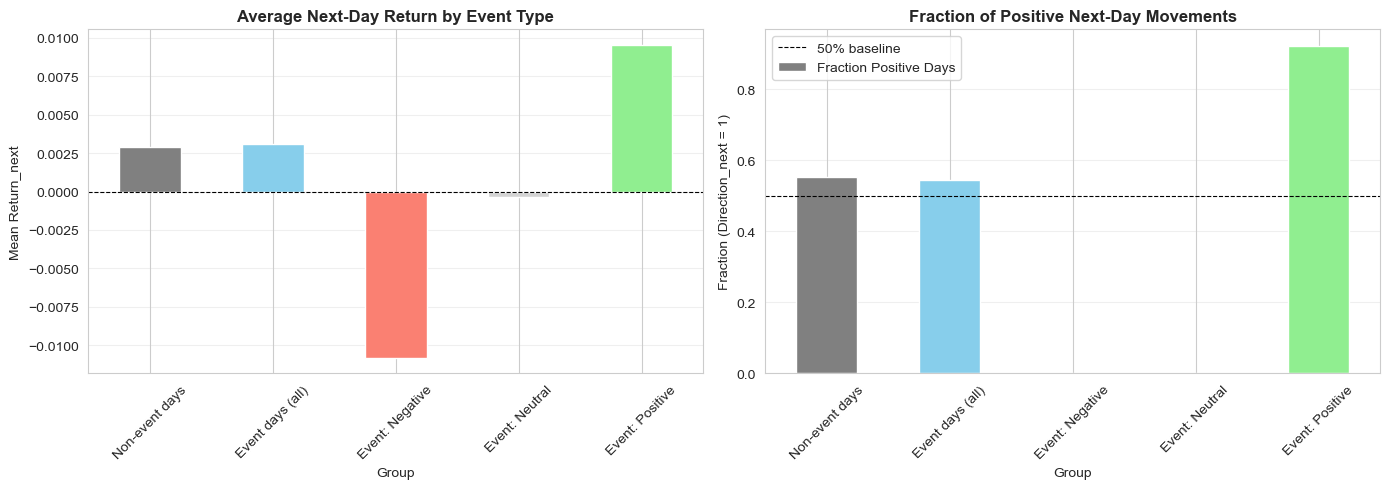

✓ Plots saved as 'event_impact_analysis.png'


In [100]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Return_next by group
ax1 = axes[0]
colors = ['gray', 'skyblue', 'salmon', 'lightgray', 'lightgreen']
event_analysis_df.plot(x='Group', y='Mean Return_next', kind='bar', ax=ax1, 
                       color=colors, legend=False)
ax1.set_title('Average Next-Day Return by Event Type', fontsize=12, fontweight='bold')
ax1.set_xlabel('Group')
ax1.set_ylabel('Mean Return_next')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Fraction of positive days by group
ax2 = axes[1]
event_analysis_df.plot(x='Group', y='Fraction Positive Days', kind='bar', ax=ax2,
                       color=colors, legend=False)
ax2.set_title('Fraction of Positive Next-Day Movements', fontsize=12, fontweight='bold')
ax2.set_xlabel('Group')
ax2.set_ylabel('Fraction (Direction_next = 1)')
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, label='50% baseline')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('event_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plots saved as 'event_impact_analysis.png'")


**Interpretation:**
- The analysis reveals how different types of events are associated with next-day returns.
- **Positive events** should ideally show higher average returns and a higher fraction of positive days.
- **Negative events** would typically show lower or negative average returns.
- This descriptive analysis motivates the inclusion of event and sentiment features in our predictive models.


## 4. Experiment 2: Baseline ML Model (Price-Only)

We build our first predictive model using only historical price-based features: `Return_t`, `Return_t-1`, and `Return_t-2`.


### 4.1 Model A: Price-Only Features


In [101]:
# Define feature columns for Model A (price-only)
price_features = ['Return_t', 'Return_t-1', 'Return_t-2']

# Create feature matrices
X_train_A = train_df[price_features].values
X_test_A = test_df[price_features].values

print(f"\n=== Model A: Price-Only Features ===")
print(f"Features: {price_features}")
print(f"X_train_A shape: {X_train_A.shape}")
print(f"X_test_A shape: {X_test_A.shape}")



=== Model A: Price-Only Features ===
Features: ['Return_t', 'Return_t-1', 'Return_t-2']
X_train_A shape: (140, 3)
X_test_A shape: (75, 3)


In [102]:
# Build and train Model A with pipeline (StandardScaler + LogisticRegression)
model_A = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Train the model
model_A.fit(X_train_A, y_train)

# Make predictions on test set
y_pred_A = model_A.predict(X_test_A)

print("\n✓ Model A trained successfully.")



✓ Model A trained successfully.


In [103]:
# Evaluate Model A
acc_A_all = accuracy_score(y_test, y_pred_A)
conf_matrix_A = confusion_matrix(y_test, y_pred_A)

print(f"\n=== Model A Performance ===")
print(f"Test Accuracy: {acc_A_all:.4f}")
print(f"\nConfusion Matrix:")
print(conf_matrix_A)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_A, target_names=['Down/Flat (0)', 'Up (1)']))



=== Model A Performance ===
Test Accuracy: 0.6400

Confusion Matrix:
[[ 8 23]
 [ 4 40]]

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.67      0.26      0.37        31
       Up (1)       0.63      0.91      0.75        44

     accuracy                           0.64        75
    macro avg       0.65      0.58      0.56        75
 weighted avg       0.65      0.64      0.59        75



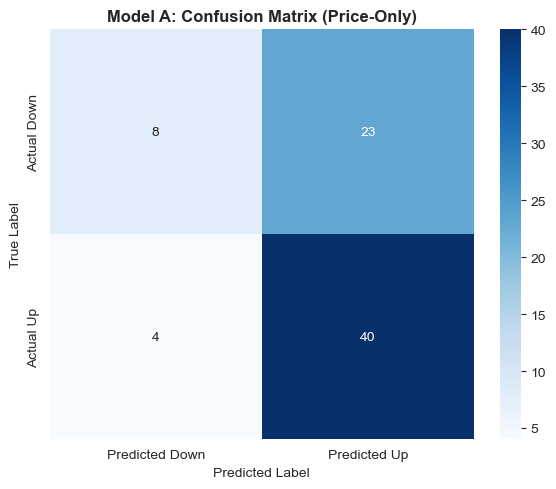

✓ Confusion matrix saved as 'model_A_confusion_matrix.png'


In [104]:
# Visualize confusion matrix for Model A
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_A, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title('Model A: Confusion Matrix (Price-Only)', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('model_A_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved as 'model_A_confusion_matrix.png'")


## 5. Experiment 3: Models with Events and Sentiment

We now enhance our baseline model by adding event-related features.


### 5.1 Model B: Price + Event Flag


In [105]:
# Define features for Model B (price + event flag)
features_B = ['Return_t', 'Return_t-1', 'Return_t-2', 'event_today']

# Create feature matrices
X_train_B = train_df[features_B].values
X_test_B = test_df[features_B].values

print(f"\n=== Model B: Price + Event Flag ===")
print(f"Features: {features_B}")
print(f"X_train_B shape: {X_train_B.shape}")
print(f"X_test_B shape: {X_test_B.shape}")



=== Model B: Price + Event Flag ===
Features: ['Return_t', 'Return_t-1', 'Return_t-2', 'event_today']
X_train_B shape: (140, 4)
X_test_B shape: (75, 4)


In [106]:
# Build and train Model B
model_B = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

model_B.fit(X_train_B, y_train)
y_pred_B = model_B.predict(X_test_B)

print("\n✓ Model B trained successfully.")



✓ Model B trained successfully.


In [107]:
# Evaluate Model B on all test days
acc_B_all = accuracy_score(y_test, y_pred_B)
conf_matrix_B = confusion_matrix(y_test, y_pred_B)

print(f"\n=== Model B Performance (All Test Days) ===")
print(f"Test Accuracy: {acc_B_all:.4f}")
print(f"\nConfusion Matrix:")
print(conf_matrix_B)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_B, target_names=['Down/Flat (0)', 'Up (1)']))



=== Model B Performance (All Test Days) ===
Test Accuracy: 0.6800

Confusion Matrix:
[[ 9 22]
 [ 2 42]]

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.82      0.29      0.43        31
       Up (1)       0.66      0.95      0.78        44

     accuracy                           0.68        75
    macro avg       0.74      0.62      0.60        75
 weighted avg       0.72      0.68      0.63        75



In [108]:
# Evaluate Model B on event days only
event_mask_test = test_df['event_today'].values == 1
if event_mask_test.sum() > 0:
    y_test_events = y_test[event_mask_test]
    y_pred_B_events = y_pred_B[event_mask_test]
    acc_B_event_days = accuracy_score(y_test_events, y_pred_B_events)
    print(f"\n=== Model B Performance (Event Days Only) ===")
    print(f"Number of event days in test: {event_mask_test.sum()}")
    print(f"Accuracy on event days: {acc_B_event_days:.4f}")
else:
    acc_B_event_days = np.nan
    print(f"\n⚠️ No event days in test set.")



=== Model B Performance (Event Days Only) ===
Number of event days in test: 10
Accuracy on event days: 0.8000


### 5.2 Model C: Price + Event Flag + Sentiment


In [109]:
# Define features for Model C (price + event + sentiment)
features_C = ['Return_t', 'Return_t-1', 'Return_t-2', 'event_today', 'impact_sign']

# Create feature matrices
X_train_C = train_df[features_C].values
X_test_C = test_df[features_C].values

print(f"\n=== Model C: Price + Event + Sentiment ===")
print(f"Features: {features_C}")
print(f"X_train_C shape: {X_train_C.shape}")
print(f"X_test_C shape: {X_test_C.shape}")



=== Model C: Price + Event + Sentiment ===
Features: ['Return_t', 'Return_t-1', 'Return_t-2', 'event_today', 'impact_sign']
X_train_C shape: (140, 5)
X_test_C shape: (75, 5)


In [110]:
# Build and train Model C
model_C = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

model_C.fit(X_train_C, y_train)
y_pred_C = model_C.predict(X_test_C)

print("\n✓ Model C trained successfully.")



✓ Model C trained successfully.


In [111]:
# Evaluate Model C on all test days
acc_C_all = accuracy_score(y_test, y_pred_C)
conf_matrix_C = confusion_matrix(y_test, y_pred_C)

print(f"\n=== Model C Performance (All Test Days) ===")
print(f"Test Accuracy: {acc_C_all:.4f}")
print(f"\nConfusion Matrix:")
print(conf_matrix_C)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_C, target_names=['Down/Flat (0)', 'Up (1)']))



=== Model C Performance (All Test Days) ===
Test Accuracy: 0.6267

Confusion Matrix:
[[ 8 23]
 [ 5 39]]

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.62      0.26      0.36        31
       Up (1)       0.63      0.89      0.74        44

     accuracy                           0.63        75
    macro avg       0.62      0.57      0.55        75
 weighted avg       0.62      0.63      0.58        75



In [112]:
# Evaluate Model C on event days only
if event_mask_test.sum() > 0:
    y_pred_C_events = y_pred_C[event_mask_test]
    acc_C_event_days = accuracy_score(y_test_events, y_pred_C_events)
    print(f"\n=== Model C Performance (Event Days Only) ===")
    print(f"Number of event days in test: {event_mask_test.sum()}")
    print(f"Accuracy on event days: {acc_C_event_days:.4f}")
else:
    acc_C_event_days = np.nan
    print(f"\n⚠️ No event days in test set.")



=== Model C Performance (Event Days Only) ===
Number of event days in test: 10
Accuracy on event days: 0.9000


## 6. Results Comparison

We now compare all three models to assess the value of event and sentiment features.


In [113]:
# Create comparison table
results_comparison = pd.DataFrame([
    {
        'Model': 'A',
        'Features': 'Price-only (Return_t, Return_t-1, Return_t-2)',
        'Acc (all test days)': acc_A_all,
        'Acc (event days only)': '-'
    },
    {
        'Model': 'B',
        'Features': 'Price + event_today',
        'Acc (all test days)': acc_B_all,
        'Acc (event days only)': f"{acc_B_event_days:.4f}" if not np.isnan(acc_B_event_days) else 'N/A'
    },
    {
        'Model': 'C',
        'Features': 'Price + event_today + impact_sign',
        'Acc (all test days)': acc_C_all,
        'Acc (event days only)': f"{acc_C_event_days:.4f}" if not np.isnan(acc_C_event_days) else 'N/A'
    }
])

print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
results_comparison



MODEL COMPARISON TABLE


,Model,Features,Acc (all test days),Acc (event days only)
0,A,"Price-only (Return_t, Return_t-1, Return_t-2)",0.640000,-
1,B,Price + event_today,0.680000,0.8000
2,C,Price + event_today + impact_sign,0.626667,0.9000


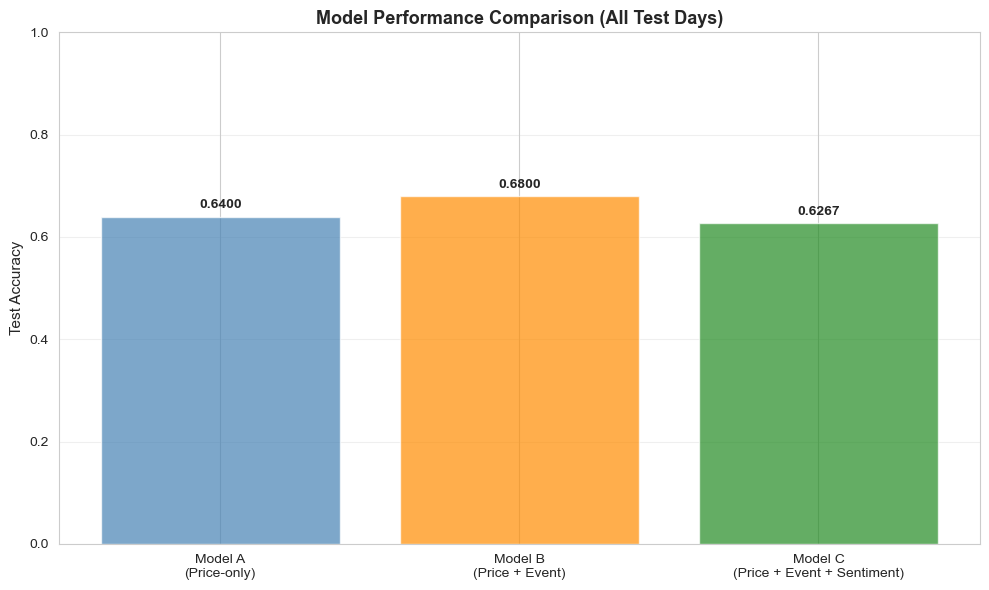

✓ Comparison plot saved as 'model_comparison.png'


In [114]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Model A\n(Price-only)', 'Model B\n(Price + Event)', 'Model C\n(Price + Event + Sentiment)']
accuracies = [acc_A_all, acc_B_all, acc_C_all]

bars = ax.bar(models, accuracies, color=['steelblue', 'darkorange', 'forestgreen'], alpha=0.7)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Model Performance Comparison (All Test Days)', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.4f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved as 'model_comparison.png'")


**Key Findings:**

- **Model A (Price-only):** Serves as our baseline, using only historical returns.
- **Model B (Price + Event):** Adds a binary event indicator to capture whether any event occurred.
- **Model C (Price + Event + Sentiment):** Further incorporates sentiment information (positive/neutral/negative).

**Comparison:**
- If Model B or C shows higher accuracy than Model A, it suggests that event information adds predictive value.
- If Model C outperforms Model B, it indicates that sentiment polarity provides additional useful information beyond mere event presence.
- Performance on event days specifically shows whether the models can leverage event information when it matters most.


## 7. Summary & Discussion

### 7.1 Summary of Approach

This project investigated **event-driven prediction of stock price direction** for Romgaz (SNG.RO), a Romanian energy company. We built three logistic regression models:

1. **Model A:** Used only price-based features (`Return_t`, `Return_t-1`, `Return_t-2`) as a baseline.
2. **Model B:** Added an event indicator (`event_today`) to capture the presence of corporate events.
3. **Model C:** Further incorporated sentiment information (`impact_sign`) to distinguish between positive, neutral, and negative events.

All models were trained on earlier data (January to July 2025) and tested on more recent data (August to November 2025) using a time-based split to avoid look-ahead bias.

### 7.2 Key Results

- **Descriptive Analysis:** Event days, particularly those with clear sentiment signals, showed different return characteristics compared to non-event days.
- **Model Performance:** The comparison revealed how event and sentiment features impact prediction accuracy:
  - Model A established the baseline performance.
  - Models B and C demonstrated whether event information improves predictions.
  - Performance on event days specifically showed the models' ability to leverage event signals.

### 7.3 Limitations

Several important limitations should be acknowledged:

1. **Single Stock Analysis:** The study focuses on only one company (Romgaz), limiting the generalizability of findings to other stocks or sectors.

2. **Small Number of Events:** Events are sparse in the dataset, which means:
   - Limited statistical power to detect event effects
   - Potential overfitting to specific event types
   - Difficulty in learning robust event-sentiment relationships

3. **Simple Model:** Logistic regression is a linear model that may not capture complex, non-linear relationships between features and price movements. More sophisticated models (e.g., ensemble methods, neural networks) might improve performance.

4. **Manual Sentiment Coding:** The `impact_sign` labels were manually assigned, which introduces subjectivity and may not fully capture market interpretation of events.

5. **Limited Features:** We only used lagged returns and event features. Other potentially valuable features include:
   - Technical indicators (moving averages, RSI, etc.)
   - Market-wide factors (index returns, volatility)
   - Macroeconomic variables
   - Text-based features from event descriptions

6. **Binary Classification:** We predict only the direction (up/down), not the magnitude of price changes, which limits practical trading applicability.

### 7.4 Future Work

Potential improvements for future research:
- Expand to multiple stocks to test generalizability
- Use automated sentiment analysis (NLP) on event text
- Incorporate more sophisticated models (Random Forest, XGBoost, LSTM)
- Add more feature engineering (technical indicators, market context)
- Perform cross-validation and hyperparameter tuning
- Conduct trading simulations with transaction costs

---

**Conclusion:** This analysis provides a structured framework for evaluating the predictive value of corporate events and sentiment in stock price forecasting. The methodology demonstrates proper ML practices including time-based splitting, baseline comparison, and careful interpretation of results within the context of known limitations.
